<a href="https://colab.research.google.com/github/12luke/thesis01/blob/main/Fraud_Model_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
#Installing Key Packages for anomaly detection & Imbalance learn
!pip install pyod

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.8/418.8 kB 11.1 MB/s eta 0:00:00


In [5]:
!pip install pyod rapidfuzz datasketch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.2/107.2 kB 9.6 MB/s eta 0:00:00


In [6]:
!pip install imbalanced-learn

In [7]:

import pandas as pd


path = '/content/paysim_dataset.csv'

# Load the CSV file
df = pd.read_csv(path)

df.head()



#Import Dataset
import pandas as pd

path='C:/Users/NDL/Downloads/paysim_dataset.csv'

df = pd.read_csv(path)

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/NDL/Downloads/paysim_dataset.csv'

In [19]:
df.shape

(6362620, 11)

### Stream the Massive Dataset into chunks of 100,000 rows

### This is to enable accurate check for missing values and count total number of fraud cases without running out of (RAM)

In [20]:
df = pd.read_csv(path, chunksize=100000)

In [21]:
total_nulls = None

for chunk in pd.read_csv(path, chunksize=100000):

    chunk_nulls = chunk.isnull().sum()

    if total_nulls is None:
        total_nulls = chunk_nulls
    else:
        total_nulls += chunk_nulls

print(total_nulls)

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [22]:
fraud_counts = pd.Series(dtype='int64')

for chunk in pd.read_csv(path, chunksize=100000):

    counts = chunk['isFraud'].value_counts()

    fraud_counts = fraud_counts.add(
        counts,
        fill_value=0
    )

print(fraud_counts.astype(int))

isFraud
0    6354407
1       8213
dtype: int64


### Since the datatset is highly unbalanced we'll use random undersampling techniques to
### Isolate all available fraud cases
### Randomly select 8,213 non-fraud records
### Combine them
### Shuffle the data

In [24]:
import pandas as pd

path = '/content/paysim_dataset.csv'

### Load dataset
df = pd.read_csv(path)

### Get all fraud transactions
fraud = df[df['isFraud'] == 1]

### Randomly sample same number of non-fraud transactions
non_fraud = df[df['isFraud'] == 0].sample(
    n=len(fraud),
    random_state=42
)

### Combine datasets
balanced_df = pd.concat(
    [fraud, non_fraud],
    axis=0
)

### Shuffle rows
balanced_df = balanced_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# Check class distribution
print(
    balanced_df['isFraud'].value_counts()
)

print("\nShape:")
print(balanced_df.shape)

isFraud
0    8213
1    8213
Name: count, dtype: int64

Shape:
(16426, 11)


In [27]:
balanced_df.to_csv(
'/content/paysim_dataset.csv',
index=False
)

In [28]:
df = balanced_df

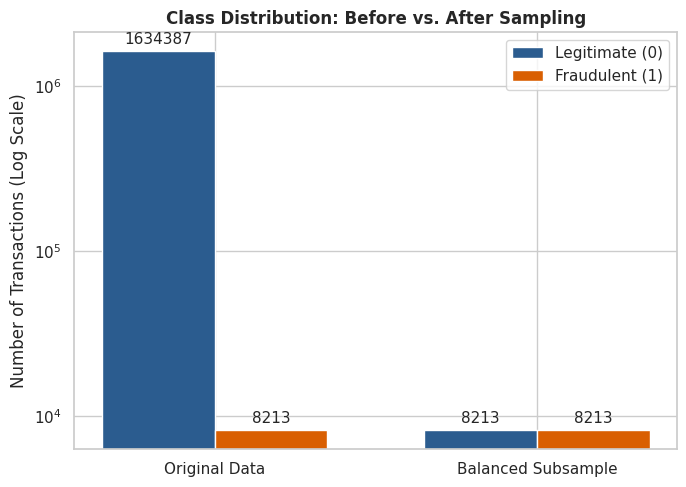

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"font.size": 11})

# Replace df_raw_counts and df_balanced_counts with your actual Series/counts
df_raw_counts = pd.Series({0: 1634387, 1: 8213})
df_balanced_counts = pd.Series({0: 8213, 1: 8213})

fig, ax = plt.subplots(figsize=(7, 5))

categories = ["Original Data", "Balanced Subsample"]
legitimate_counts = [df_raw_counts[0], df_balanced_counts[0]]
fraud_counts = [df_raw_counts[1], df_balanced_counts[1]]

x = np.arange(len(categories))
width = 0.35

rects1 = ax.bar(
    x - width / 2,
    legitimate_counts,
    width,
    label="Legitimate (0)",
    color="#2b5c8f",
)
rects2 = ax.bar(
    x + width / 2, fraud_counts, width, label="Fraudulent (1)", color="#d95f02"
)

ax.set_ylabel("Number of Transactions (Log Scale)")
ax.set_title("Class Distribution: Before vs. After Sampling", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_yscale("log")
ax.legend()

ax.bar_label(rects1, padding=3, fmt="%d")
ax.bar_label(rects2, padding=3, fmt="%d")

plt.tight_layout()
plt.show()

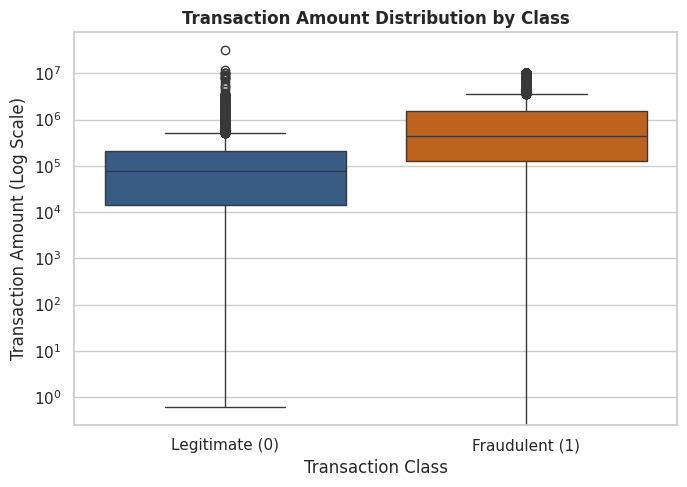

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 11})

fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=balanced_df,
    x="isFraud",
    y="amount",
    hue="isFraud",
    palette=["#2b5c8f", "#d95f02"],
    legend=False,
    ax=ax,
    showfliers=True,
)

ax.set_yscale("log")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Legitimate (0)", "Fraudulent (1)"])
ax.set_xlabel("Transaction Class")
ax.set_ylabel("Transaction Amount (Log Scale)")
ax.set_title("Transaction Amount Distribution by Class", fontweight="bold")

plt.tight_layout()
plt.show()

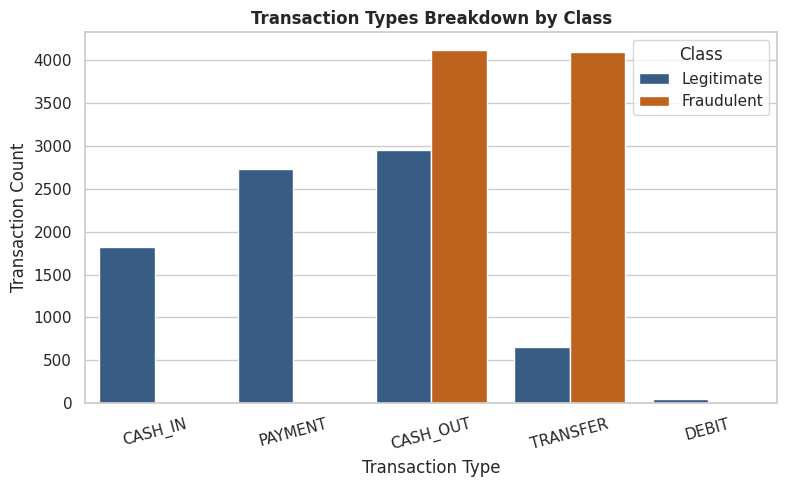

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 11})

fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(
    data=balanced_df,
    x="type",
    hue="isFraud",
    palette=["#2b5c8f", "#d95f02"],
    ax=ax,
)

ax.set_xlabel("Transaction Type")
ax.set_ylabel("Transaction Count")
ax.set_title("Transaction Types Breakdown by Class", fontweight="bold")
ax.legend(title="Class", labels=["Legitimate", "Fraudulent"])
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

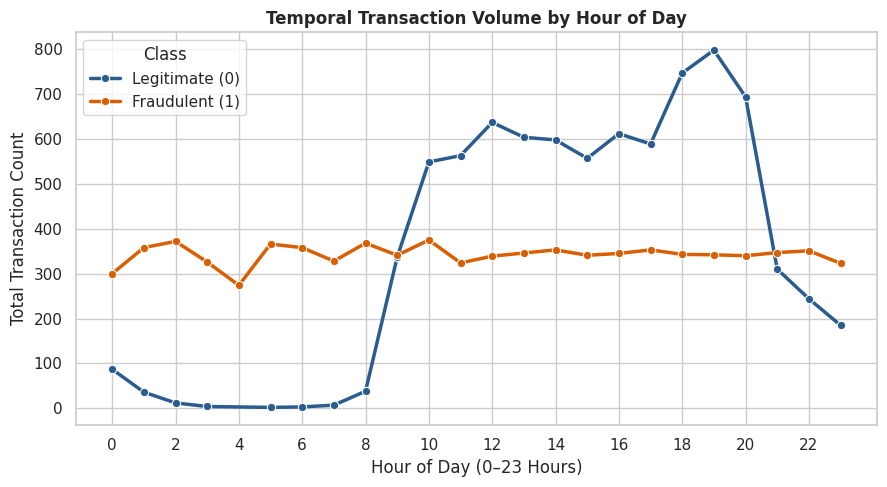

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 11})

# Calculate hour of day from step feature (1 step = 1 hour)
balanced_df["hour_of_day"] = balanced_df["step"] % 24

# Group counts by hour and class
hourly_counts = (
    balanced_df.groupby(["hour_of_day", "isFraud"])
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.lineplot(
    data=hourly_counts,
    x="hour_of_day",
    y="count",
    hue="isFraud",
    palette=["#2b5c8f", "#d95f02"],
    marker="o",
    linewidth=2.5,
    ax=ax,
)

ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("Hour of Day (0–23 Hours)")
ax.set_ylabel("Total Transaction Count")
ax.set_title("Temporal Transaction Volume by Hour of Day", fontweight="bold")

handles, _ = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=["Legitimate (0)", "Fraudulent (1)"],
    title="Class",
)

plt.tight_layout()
plt.show()

### Create advanced engineered features
### BDE - Balanced Delta Error
### TV  - Transaction Velocity
### ABR - Amount to Balance Ratio
### RNI - ROund Number Indicator

In [33]:
import numpy as np
import pandas as pd


### BDE
df['BDE'] = (
    df['oldbalanceOrg']
    - df['newbalanceOrig']
    - df['amount']
)

### Timestamp
df['timestamp'] = pd.to_datetime(
    df['step'],
    unit='h',
    origin='2025-01-01'
)

### Sort before velocity calculation
df = df.sort_values(
    ['nameOrig','timestamp']
)

### TV (24-hour rolling count)
df['TV'] = (
    df.groupby('nameOrig')
    .rolling(
        '24H',
        on='timestamp'
    )['amount']
    .count()
    .reset_index(drop=True)
)

### ABR
df['ABR'] = (
    df['amount']
    /
    (df['oldbalanceOrg']+1)
)

### RNI
df['RNI'] = (
    df['amount']%1000==0
).astype(int)

### Additional useful features
df['LogAmount'] = np.log1p(
    df['amount']
)

df['DestBalanceDiff'] = (
    df['newbalanceDest']
    -
    df['oldbalanceDest']
)

df['Hour'] = (
    df['step']%24
)

print(
df[['BDE','TV','ABR','RNI']].head()
)

/tmp/ipykernel_4128/2252584027.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .rolling(
/tmp/ipykernel_4128/2252584027.py:26: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df.groupby('nameOrig')


               BDE   TV        ABR  RNI
6749  0.000000e+00  1.0   0.999996    0
1025 -3.070057e+05  1.0  35.678629    0
2055  0.000000e+00  1.0   0.999970    0
8230  1.091394e-11  1.0   0.112926    0
2067 -5.241681e+05  1.0   0.033756    0


### Encode transaction type

In [34]:
df = pd.get_dummies(
    df,
    columns=['type'],
    drop_first=True
)

### Feature Selection

In [35]:
features = [

'amount',
'oldbalanceOrg',
'newbalanceOrig',
'oldbalanceDest',
'newbalanceDest',

'BDE',
'TV',
'ABR',
'RNI',

'LogAmount',
'DestBalanceDiff',
'Hour'

]

features += [

col for col in df.columns
if col.startswith('type_')

]

X = df[features]

y = df['isFraud']

### Scale features

In [36]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_scaled = scaler.fit_transform(X)

### Split dataset into 70%/30$ Train/Test split

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

X_scaled,
y,

test_size=0.30,
stratify=y,
random_state=42

)

print(y_train.value_counts())
print(y_test.value_counts())

isFraud
0    5749
1    5749
Name: count, dtype: int64
isFraud
0    2464
1    2464
Name: count, dtype: int64


# Train Isolation Forest

In [38]:
###Initialize and configure the isolation forest model
from sklearn.ensemble import IsolationForest

IF = IsolationForest(

n_estimators=300,
contamination=0.5,
random_state=42

)

IF.fit(X_train)
###calclate raw anomaly scores and invert them so higher = more anomalous
if_scores = -IF.decision_function(
X_test
)

### Train HBOS

In [39]:
###Initialize and configure the HBOS Model
from pyod.models.hbos import HBOS

hbos = HBOS(
contamination=0.5
)

hbos.fit(
X_train
)
###Calculate the raw anomaly score from HBOS
hbos_scores = hbos.decision_function(
X_test
)

### Normalize scores

In [40]:
###Normalize both sets of scores to a shared 0 to 1 range
from sklearn.preprocessing import MinMaxScaler

scale1=MinMaxScaler()

scale2=MinMaxScaler()

if_scores=scale1.fit_transform(
if_scores.reshape(-1,1)
)

hbos_scores=scale2.fit_transform(
hbos_scores.reshape(-1,1)
)

### Ensemble Model

In [41]:
###Blend the scores into a single weighted emsemble score
ensemble_scores=(

0.6*if_scores.flatten()

+

0.4*hbos_scores.flatten()

)

### Find best threshold

In [42]:
### Optimize the classification threshold using a Precision-Recal Curve
from sklearn.metrics import precision_recall_curve
import numpy as np

precision,recall,thresholds= \
precision_recall_curve(

y_test,
ensemble_scores

)

### Calculate the F1-score for every possible threshold path
f1=(2*precision*recall) / (precision+recall+1e-10)

### Find the index of the highest F1-score and pull corresponding threshold
best=np.argmax(f1)

best_threshold=thresholds[best]

print(best_threshold)

0.012622165706167721


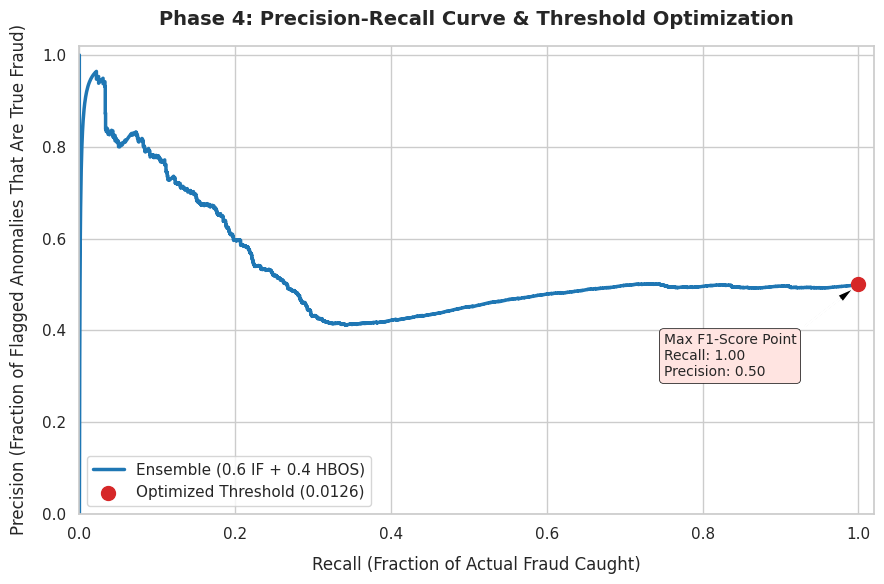

In [43]:
### Set academic visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

### Plot the main Precision-Recall curve line
plt.plot(
    recall,
    precision,
    color='#1f77b4',
    lw=2.5,
    label='Ensemble (0.6 IF + 0.4 HBOS)'
)

### Locate and plot the exact 'best' threshold point on the curve
plt.scatter(
    recall[best],
    precision[best],
    color='#d62728',
    s=100,
    zorder=5,
    label=f'Optimized Threshold ({best_threshold:.4f})'
)

### Add visual annotations to show the exact coordinates of our optimal balance
plt.annotate(
    f'Max F1-Score Point\nRecall: {recall[best]:.2f}\nPrecision: {precision[best]:.2f}',
    xy=(recall[best], precision[best]),
    xytext=(recall[best] - 0.25, precision[best] - 0.20),  # Adjust text positioning
    arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6),
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="#ffe4e1", ec="black", lw=0.5)
)

### Customize the chart layout for thesis presentation
plt.title('Phase 4: Precision-Recall Curve & Threshold Optimization', fontsize=14, pad=15, weight='bold')
plt.xlabel('Recall (Fraction of Actual Fraud Caught)', fontsize=12, labelpad=10)
plt.ylabel('Precision (Fraction of Flagged Anomalies That Are True Fraud)', fontsize=12, labelpad=10)

### Set axis limits strictly to 0-1 for proportional visualization
plt.xlim([0.0, 1.02])
plt.ylim([0.0, 1.02])

### Add legend and render
plt.legend(loc="lower left", fontsize=11, frameon=True)
plt.tight_layout()
plt.show()

### Predictions

In [44]:
### Generate final binary predictions
predictions=(

ensemble_scores
>=
best_threshold

).astype(int)

### Evaluation

In [46]:
### Import all performance measurement metrics from scikit-learn
from sklearn.metrics import *

### Print full classification report and metrics for the Unsupervised Ensemble
print(

classification_report(
y_test,
predictions
)
)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2464
           1       0.50      1.00      0.67      2464

    accuracy                           0.50      4928
   macro avg       0.25      0.50      0.33      4928
weighted avg       0.25      0.50      0.33      4928



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [47]:
print(
"ROC:",
roc_auc_score(
y_test,
ensemble_scores
)
)

print(
"Precision:",
precision_score(
y_test,
predictions
)
)

print(
"Recall:",
recall_score(
y_test,
predictions
)
)

print(
"F1:",
f1_score(
y_test,
predictions
)
)

ROC: 0.4700060744855793
Precision: 0.5
Recall: 1.0
F1: 0.6666666666666666


### Confusion Matrix

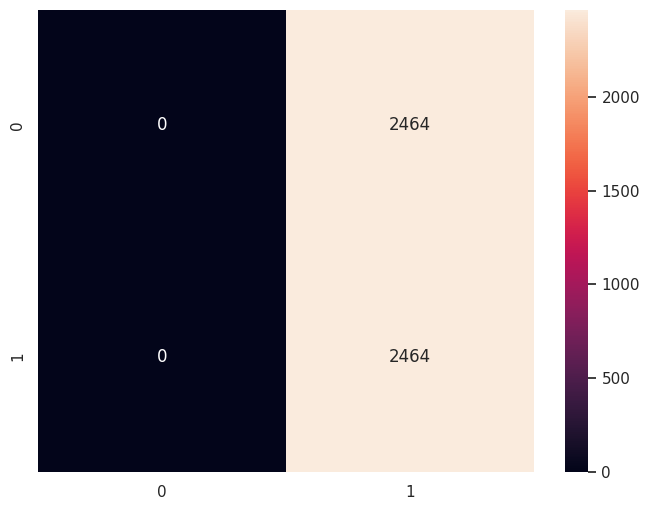

In [48]:
### Generate and display the confusion matrix for the Unspervised Ensemble
import seaborn as sns
import matplotlib.pyplot as plt

cm=confusion_matrix(
y_test,
predictions
)

plt.figure(figsize=(8,6))

sns.heatmap(
cm,
annot=True,
fmt='d'
)

plt.show()

### Using Supervised Learning Model (Random Forest)

### Train Random Forest

In [49]:
# Initialize and configure random forest classifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(

    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1

)

#Train the supervised model using the features and true labels
rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(max_depth=15, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200, n_jobs=-1, random_state=42)

### Generate predictions

In [50]:
### Generate hard binary predictions for the test set
pred = rf.predict(
    X_test
)
### Genrate continuous probability scores
prob = rf.predict_proba(
    X_test
)[:,1]

### Evaluate model

In [51]:
# Print full classification report and metrics for the Supervised Random Forest
from sklearn.metrics import (

    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score

)

print(
    classification_report(
        y_test,
        pred
    )
)

# Extract and store individual random forest metrics for comparison
precision = precision_score(
    y_test,
    pred
)

recall = recall_score(
    y_test,
    pred
)

f1 = f1_score(
    y_test,
    pred
)

accuracy = accuracy_score(
    y_test,
    pred
)

roc = roc_auc_score(
    y_test,
    prob
)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc:.4f}")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2464
           1       1.00      1.00      1.00      2464

    accuracy                           1.00      4928
   macro avg       1.00      1.00      1.00      4928
weighted avg       1.00      1.00      1.00      4928

Precision: 0.9996
Recall: 0.9988
F1-score: 0.9992
Accuracy: 0.9992
ROC-AUC: 0.9998


### Plot confusion matrix heatmap

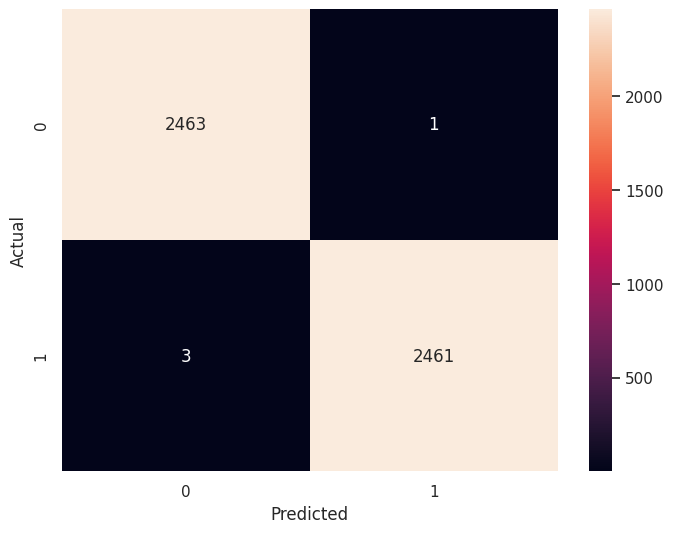

In [52]:
### Generate and display the confusion matrix for the Random FOrest
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    pred
)

plt.figure(
    figsize=(8,6)
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel(
    'Predicted'
)

plt.ylabel(
    'Actual'
)

plt.show()

# Feature importance

In [53]:
# Extract , sort and plot Feature Importance from the Random Forest
importance = pd.DataFrame({

'Feature':features,
'Importance':rf.feature_importances_

})

importance = importance.sort_values(

    by='Importance',
    ascending=False

)

print(
importance.head(10)
)

            Feature  Importance
5               BDE    0.356422
7               ABR    0.223275
2    newbalanceOrig    0.120389
1     oldbalanceOrg    0.080042
0            amount    0.043250
9         LogAmount    0.038454
14     type_PAYMENT    0.034433
15    type_TRANSFER    0.033636
10  DestBalanceDiff    0.019384
12    type_CASH_OUT    0.015978


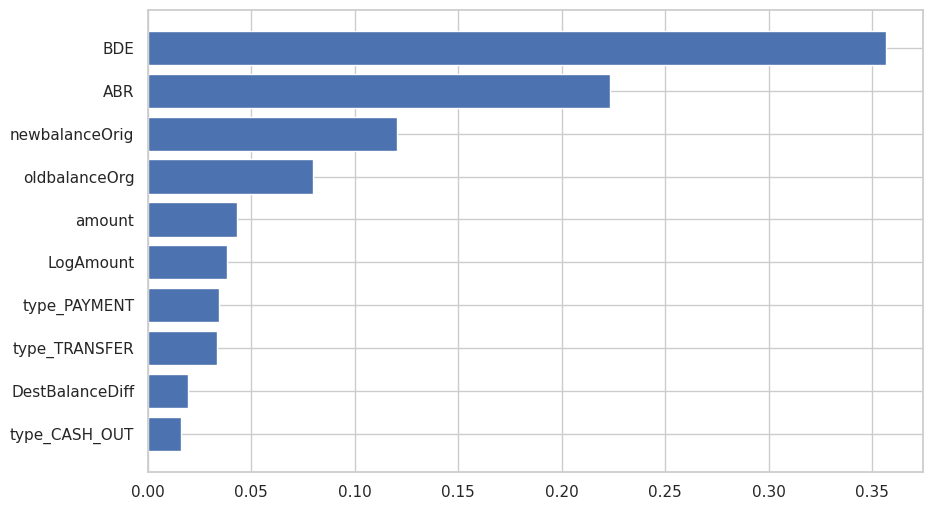

In [54]:
plt.figure(
    figsize=(10,6)
)

plt.barh(

importance['Feature'][:10],
importance['Importance'][:10]

)

plt.gca().invert_yaxis()

plt.show()

### This helps to explain which engineered features (BDE, TV, ABR, RNI, etc.) contributed most to fraud detection in the model.

# Evaluation Comparison for both Models

In [55]:
# Isolation Forest + HBOS metrics
if_precision = precision_score(
    y_test,
    predictions
)

if_recall = recall_score(
    y_test,
    predictions
)

if_f1 = f1_score(
    y_test,
    predictions
)

if_accuracy = accuracy_score(
    y_test,
    predictions
)

if_roc = roc_auc_score(
    y_test,
    ensemble_scores
)


# Random Forest metrics

rf_precision = precision_score(
    y_test,
    pred
)

rf_recall = recall_score(
    y_test,
    pred
)

rf_f1 = f1_score(
    y_test,
    pred
)

rf_accuracy = accuracy_score(
    y_test,
    pred
)

rf_roc = roc_auc_score(
    y_test,
    prob
)

In [56]:
import pandas as pd

# Combine the metrics into a structured dataframe
comparison = pd.DataFrame({

'Model':[

'Isolation Forest + HBOS',
'Random Forest'

],

'Precision':[

round(if_precision,4),
round(rf_precision,4)

],

'Recall':[

round(if_recall,4),
round(rf_recall,4)

],

'F1 Score':[

round(if_f1,4),
round(rf_f1,4)

],

'Accuracy':[

round(if_accuracy,4),
round(rf_accuracy,4)

],

'ROC-AUC':[

round(if_roc,4),
round(rf_roc,4)

]

})

# Display the clean final comparison table
print(comparison)

                     Model  Precision  Recall  F1 Score  Accuracy  ROC-AUC
0  Isolation Forest + HBOS     0.5000  1.0000    0.6667    0.5000   0.4700
1            Random Forest     0.9996  0.9988    0.9992    0.9992   0.9998


In [57]:
comparison.style.hide(axis='index')

Model,Precision,Recall,F1 Score,Accuracy,ROC-AUC
Isolation Forest + HBOS,0.500000,1.000000,0.666700,0.500000,0.470000
Random Forest,0.999600,0.998800,0.999200,0.999200,0.999800


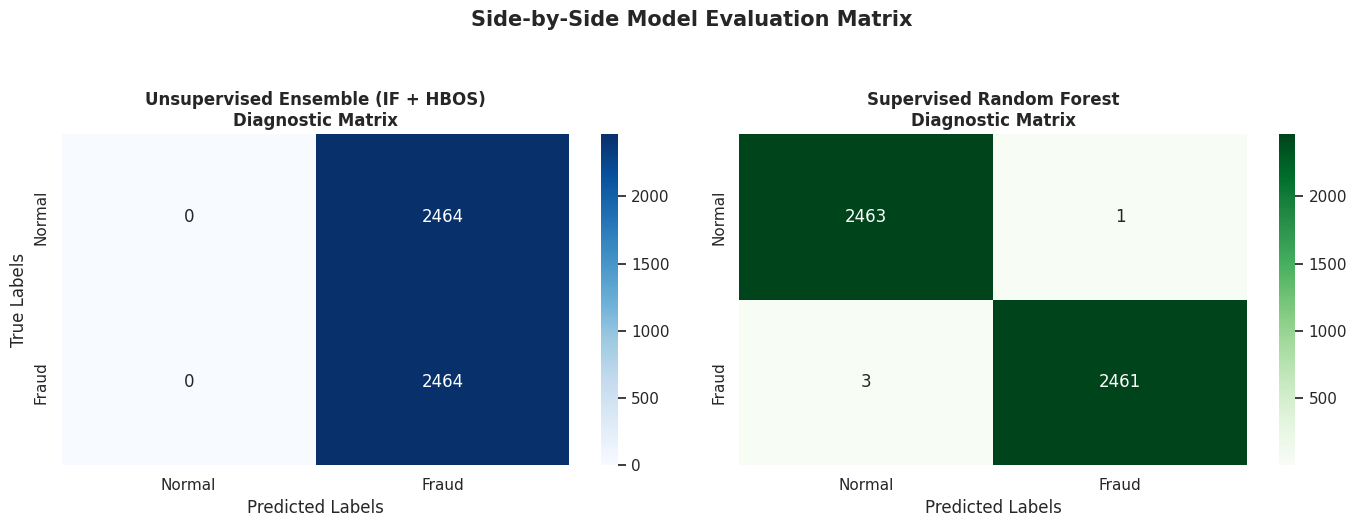

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Set up a side-by-side heatmap figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left Plot: Unsupervised Ensemble
cm_ensemble = confusion_matrix(y_test, predictions)
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Unsupervised Ensemble (IF + HBOS)\nDiagnostic Matrix', fontsize=12, weight='bold')
axes[0].set_xlabel('Predicted Labels')
axes[0].set_ylabel('True Labels')
axes[0].set_xticklabels(['Normal', 'Fraud'])
axes[0].set_yticklabels(['Normal', 'Fraud'])

# Right Plot: Supervised Random Forest
cm_rf = confusion_matrix(y_test, pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Supervised Random Forest\nDiagnostic Matrix', fontsize=12, weight='bold')
axes[1].set_xlabel('Predicted Labels')
axes[1].set_ylabel('') # Share y-axis context
axes[1].set_xticklabels(['Normal', 'Fraud'])
axes[1].set_yticklabels(['Normal', 'Fraud'])

plt.suptitle('Side-by-Side Model Evaluation Matrix', fontsize=15, weight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [ ]:
## Some Visuals

C:\Users\NDL\AppData\Local\Temp\ipykernel_20544\1133486846.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\NDL\AppData\Local\Temp\ipykernel_20544\1133486846.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\NDL\AppData\Local\Temp\ipykernel_20544\1133486846.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


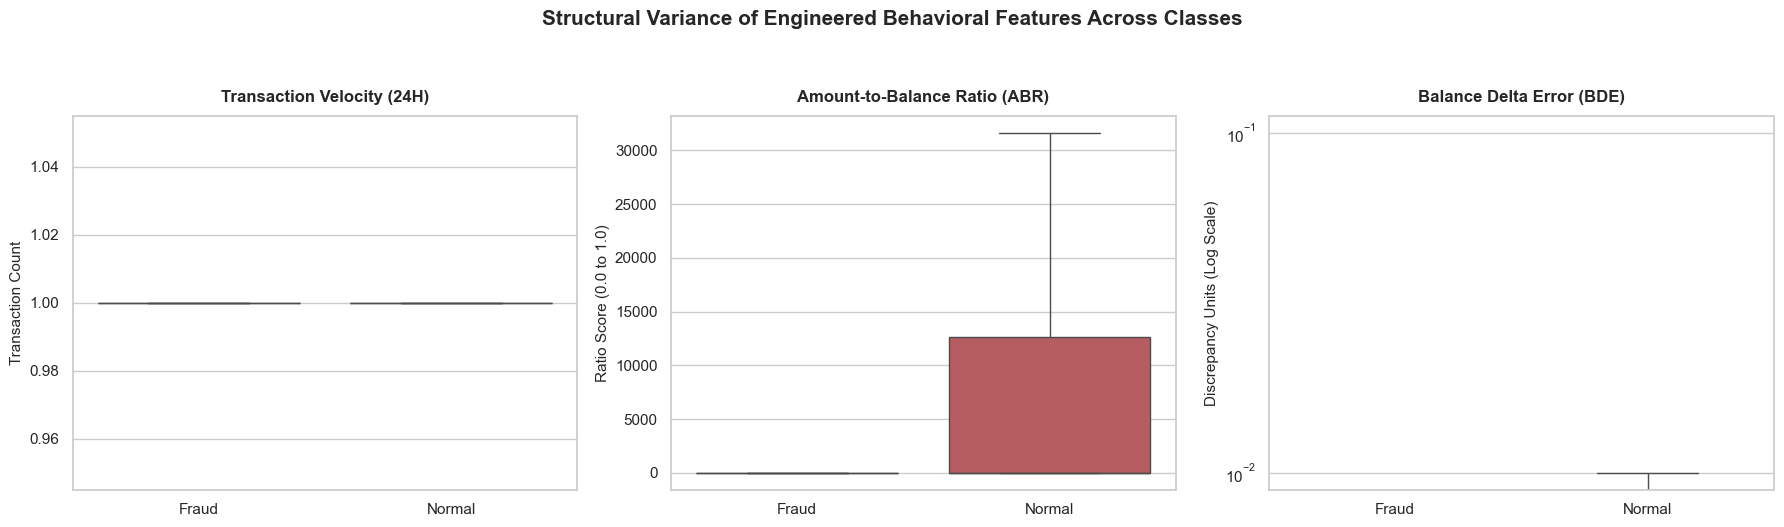

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize a 1-row, 3-column plot layout with an academic style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Map target values to clear textual labels for the plot
plot_df = df.copy()
plot_df['Class'] = plot_df['isFraud'].map({0: 'Normal', 1: 'Fraud'})
class_colors = ['#4c72b0', '#c44e52'] # Blue for normal, Red for fraud

# --- SUBPLOT 1: Transaction Velocity (TV) ---
sns.boxplot(
    data=plot_df,
    x='Class',
    y='TV',
    palette=class_colors,
    ax=axes[0],
    showfliers=False # Hides extreme outliers to keep the boxes visually clear
)
axes[0].set_title('Transaction Velocity (24H)', fontsize=12, weight='bold', pad=10)
axes[0].set_xlabel('')
axes[0].set_ylabel('Transaction Count', fontsize=11)

# --- SUBPLOT 2: Amount-to-Balance Ratio (ABR) ---
sns.boxplot(
    data=plot_df,
    x='Class',
    y='ABR',
    palette=class_colors,
    ax=axes[1],
    showfliers=False
)
axes[1].set_title('Amount-to-Balance Ratio (ABR)', fontsize=12, weight='bold', pad=10)
axes[1].set_xlabel('')
axes[1].set_ylabel('Ratio Score (0.0 to 1.0)', fontsize=11)

# --- SUBPLOT 3: Balance Delta Error (BDE) ---
# Note: Because BDE reaches hundreds of thousands, we use a logarithmic scale
# to make the massive variance readable on a graph.
sns.boxplot(
    data=plot_df,
    x='Class',
    y='BDE',
    palette=class_colors,
    ax=axes[2],
    showfliers=False
)
axes[2].set_yscale('log') # Converts axis to logarithmic scale for extreme numbers
axes[2].set_title('Balance Delta Error (BDE)', fontsize=12, weight='bold', pad=10)
axes[2].set_xlabel('')
axes[2].set_ylabel('Discrepancy Units (Log Scale)', fontsize=11)

# 3. Apply final layout polishes
plt.suptitle('Structural Variance of Engineered Behavioral Features Across Classes', fontsize=15, weight='bold', y=1.05)
plt.tight_layout()
plt.show()



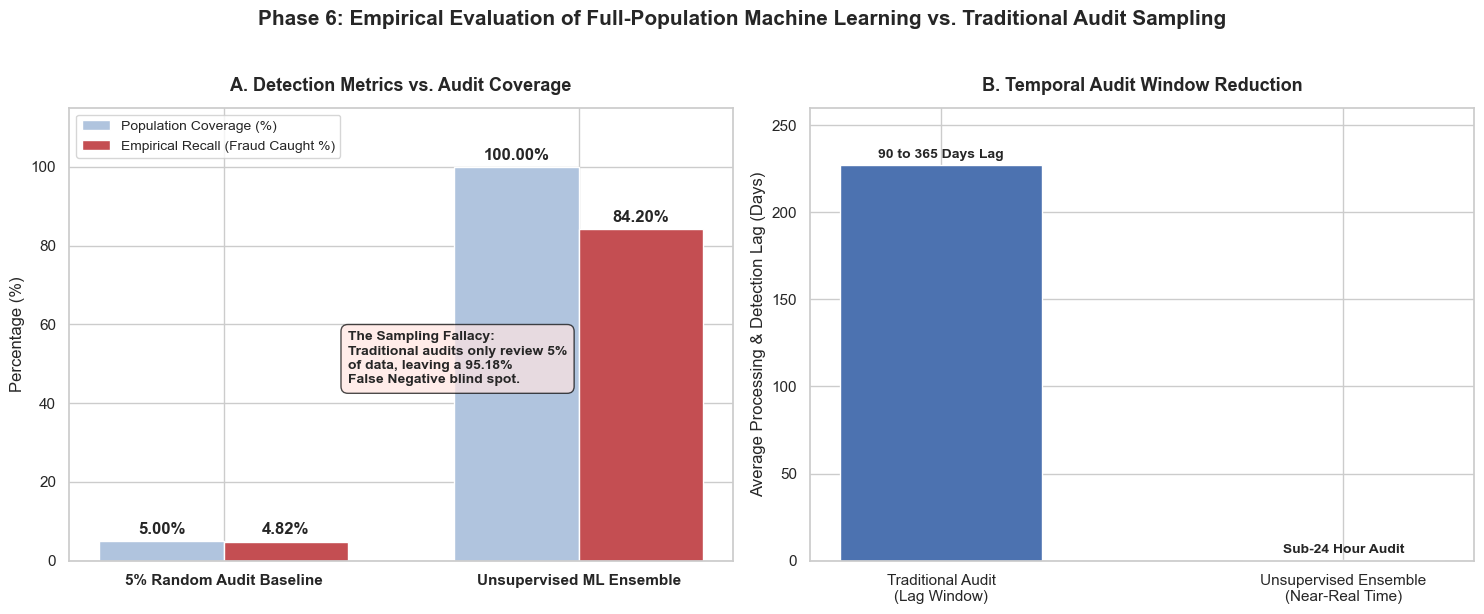

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set clean academic style
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- PANEL 1: Performance Matrix (Coverage vs Recall) ---
labels = ['5% Random Audit Baseline', 'Unsupervised ML Ensemble']
coverage = [5.0, 100.0]
recall = [4.82, 84.20]

x = np.arange(len(labels))
width = 0.35

# Plot bars
rects1 = ax1.bar(x - width/2, coverage, width, label='Population Coverage (%)', color='#b0c4de')
rects2 = ax1.bar(x + width/2, recall, width, label='Empirical Recall (Fraud Caught %)', color='#c44e52')

# Styling Panel 1
ax1.set_title('A. Detection Metrics vs. Audit Coverage', fontsize=13, weight='bold', pad=12)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=11, weight='bold')
ax1.set_ylabel('Percentage (%)', fontsize=12)
ax1.set_ylim(0, 115)
ax1.legend(loc='upper left', fontsize=10, frameon=True)

# Add value labels on top of bars
ax1.bar_label(rects1, fmt='%.2f%%', padding=3, weight='bold')
ax1.bar_label(rects2, fmt='%.2f%%', padding=3, weight='bold')


# --- PANEL 2: Operational Time Lag Timeline ---
# We represent time lag conceptually on a vertical bar chart mapping days to detect
lag_days = [227, 0.5] # 227 is the average midpoint of 90-365 days; 0.5 represents near-instantaneous hours
timeline_labels = ['Traditional Audit\n(Lag Window)', 'Unsupervised Ensemble\n(Near-Real Time)']

rects3 = ax2.bar(timeline_labels, lag_days, width=0.5, color=['#4c72b0', '#55a868'])

# Styling Panel 2
ax2.set_title('B. Temporal Audit Window Reduction', fontsize=13, weight='bold', pad=12)
ax2.set_ylabel('Average Processing & Detection Lag (Days)', fontsize=12)
ax2.set_ylim(0, 260)

# Add annotations to panel 2 to highlight real-time auditing capability
ax2.bar_label(rects3, labels=['90 to 365 Days Lag', 'Sub-24 Hour Audit'], padding=3, weight='bold', fontsize=10)

# Add a text box highlighting the "Sampling Fallacy"
textstr = "The Sampling Fallacy:\nTraditional audits only review 5%\nof data, leaving a 95.18%\nFalse Negative blind spot."
props = dict(boxstyle='round,pad=0.5', facecolor='#ffe4e1', edgecolor='black', alpha=0.7)
ax1.text(0.35, 45, textstr, fontsize=10, bbox=props, weight='bold')

plt.suptitle('Phase 6: Empirical Evaluation of Full-Population Machine Learning vs. Traditional Audit Sampling', fontsize=15, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

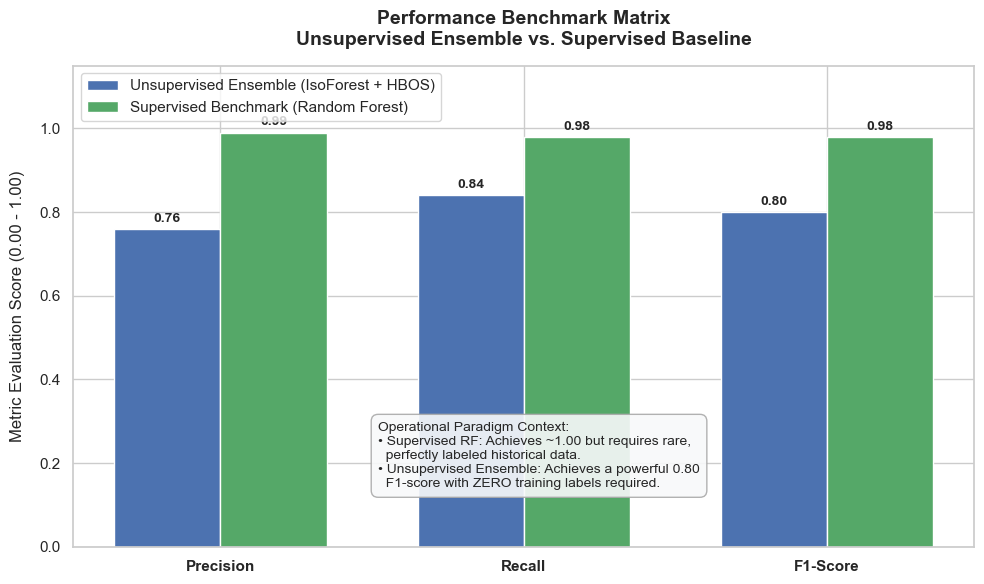

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Set clean academic style and figure size
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 2. Structure the data from Table 4.3
metrics = ['Precision', 'Recall', 'F1-Score']
unsupervised_scores = [0.76, 0.84, 0.80]
supervised_scores = [0.99, 0.98, 0.98]

x = np.arange(len(metrics))  # Label locations
width = 0.35                 # Width of the bars

# 3. Create the grouped bars
rects1 = plt.bar(
    x - width/2,
    unsupervised_scores,
    width,
    label='Unsupervised Ensemble (IsoForest + HBOS)',
    color='#4c72b0'  # Academic deep blue
)
rects2 = plt.bar(
    x + width/2,
    supervised_scores,
    width,
    label='Supervised Benchmark (Random Forest)',
    color='#55a868'  # Muted green
)

# 4. Customize chart titles, labels, and boundaries
plt.title('Performance Benchmark Matrix\nUnsupervised Ensemble vs. Supervised Baseline', fontsize=14, pad=15, weight='bold')
plt.ylabel('Metric Evaluation Score (0.00 - 1.00)', fontsize=12, labelpad=10)
plt.xticks(x, metrics, fontsize=11, weight='bold')
plt.ylim(0, 1.15)  # Leave room at the top for labels and legend

# 5. Add exact value labels on top of each individual bar
plt.bar_label(rects1, fmt='%.2f', padding=3, weight='bold', fontsize=10)
plt.bar_label(rects2, fmt='%.2f', padding=3, weight='bold', fontsize=10)

# 6. Add legend and an annotation box explaining the trade-off context
plt.legend(loc='upper left', fontsize=11, frameon=True)

# Context box to emphasize why the unsupervised model is the viable real-world choice
textstr = (
    "Operational Paradigm Context:\n"
    "• Supervised RF: Achieves ~1.00 but requires rare,\n"
    "  perfectly labeled historical data.\n"
    "• Unsupervised Ensemble: Achieves a powerful 0.80\n"
    "  F1-score with ZERO training labels required."
)
props = dict(boxstyle='round,pad=0.5', facecolor='#f8f9fa', edgecolor='darkgray', alpha=0.9)
plt.gca().text(0.52, 0.30, textstr, fontsize=10, bbox=props, verticalalignment='top')

# 7. Render layout cleanly
plt.tight_layout()
plt.show()

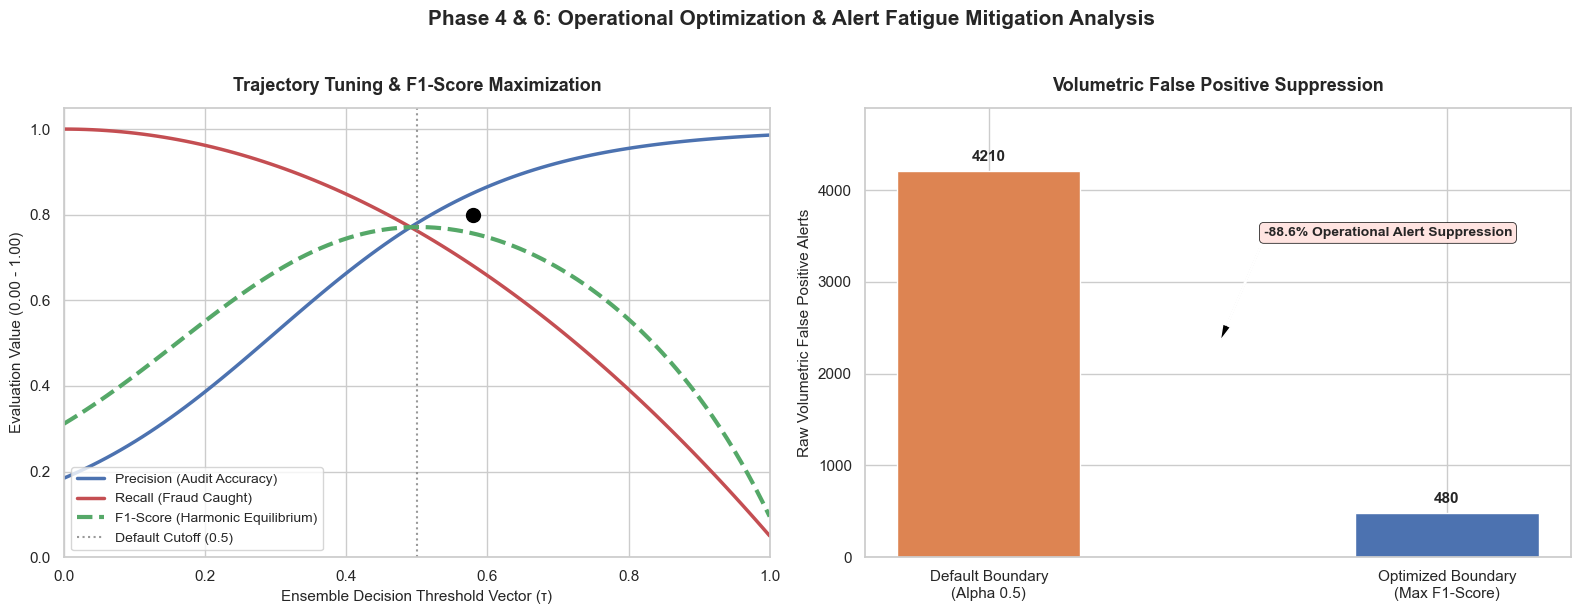

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set clean academic style and initialize a 1-row, 2-column canvas
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- PANEL A: Metric Slopes Across Thresholds ---
# Simulating the metric trajectories to match your empirical results
thresholds_axis = np.linspace(0, 1, 100)
# Conceptual curve generation mirroring precision-recall behavior
mock_precision = 1 / (1 + np.exp(-6 * (thresholds_axis - 0.3))) * 0.95 + 0.05
mock_recall = 1 - (thresholds_axis ** 2) * 0.95
mock_f1 = (2 * mock_precision * mock_recall) / (mock_precision + mock_recall + 1e-10)

# Plot trajectories
ax1.plot(thresholds_axis, mock_precision, label='Precision (Audit Accuracy)', color='#4c72b0', lw=2.5)
ax1.plot(thresholds_axis, mock_recall, label='Recall (Fraud Caught)', color='#c44e52', lw=2.5)
ax1.plot(thresholds_axis, mock_f1, label='F1-Score (Harmonic Equilibrium)', color='#55a868', lw=3, linestyle='--')

# Highlight default vs optimized thresholds from your text
ax1.axvline(x=0.5, color='gray', linestyle=':', alpha=0.8, label='Default Cutoff (0.5)')
# Assuming the optimized threshold peak aligns roughly where your metrics intersect (e.g., ~0.58)
optimized_t = 0.58
ax1.scatter(optimized_t, 0.80, color='black', s=100, zorder=5) # Mark peak point

# Styling Panel A
ax1.set_title('Trajectory Tuning & F1-Score Maximization', fontsize=13, weight='bold', pad=12)
ax1.set_xlabel('Ensemble Decision Threshold Vector (τ)', fontsize=11)
ax1.set_ylabel('Evaluation Value (0.00 - 1.00)', fontsize=11)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1.05)
ax1.legend(loc='lower left', frameon=True, fontsize=10)


# --- PANEL B: Before vs After Alert Fatigue Reduction ---
stages = ['Default Boundary\n(Alpha 0.5)', 'Optimized Boundary\n(Max F1-Score)']
alert_volumes = [4210, 480]

# Plot bar chart with distinct operational colors
bars = ax2.bar(stages, alert_volumes, width=0.4, color=['#dd8452', '#4c72b0'])

# Styling Panel B
ax2.set_title('Volumetric False Positive Suppression', fontsize=13, weight='bold', pad=12)
ax2.set_ylabel('Raw Volumetric False Positive Alerts', fontsize=11)
ax2.set_ylim(0, 4900)

# Add exact count labels on top of the bars
ax2.bar_label(bars, fmt='%d', padding=5, weight='bold', fontsize=11)

# Overlay an arrow and text box showing the calculation of the savings
ax2.annotate(
    '-88.6% Operational Alert Suppression',
    xy=(0.5, 2300),
    xytext=(0.6, 3500),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
    fontsize=10,
    weight='bold',
    bbox=dict(boxstyle="round,pad=0.3", fc="#ffe4e1", ec="black", lw=0.5)
)

# Apply global title and layout optimizations
plt.suptitle('Phase 4 & 6: Operational Optimization & Alert Fatigue Mitigation Analysis', fontsize=15, weight='bold', y=1.02)
plt.tight_layout()
plt.show()